


Environment: Python 3.11.7 and Jupyter notebook


## Introduction
This notebook represents a systematic approach to conducting feature extraction and model training on preprocessed review text data. The primary objectives of this notebook are as follows:
1. To convert the preprocessed review text into numerical representations suitable for machine learning applications.
2. To employ various techniques, including Bag-of-Words, Unweighted Embeddings, and TF-IDF Weighted Embeddings, for effective feature extraction.
3. To train classification models such as Logistic Regression, Decision Tree, and Random Forest utilizing the extracted features.
4. To implement 5-fold cross-validation as a method for robust performance evaluation of the trained models.
5. To analyze the performance results using key evaluation metrics, including Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In these tasks, the focus shifts from preprocessing to feature extraction and model training. The preprocessed review text is converted into numerical representations using various techniques, which are then used to train classification models. Through cross-validation, each model's performance is evaluated across different folds, ensuring reliable results. The final output provides insights into how well the models perform based on multiple evaluation metrics, helping to identify the best approach for classifying the reviews.


## Importing libraries 

In [16]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.decomposition import TruncatedSVD


## Task 2. Generating Feature Representations for Clothing Items Reviews

The task is to convert the preprocessed review text into numerical representations using the following techniques:
1. Bag-of-Words (BoW)
2. Unweighted Embeddings
3. TF-IDF Weighted Embeddings

Task 2 focuses on transforming the cleaned review text into numerical formats using these techniques, each providing a distinct perspective on the structure and content of the reviews. These features are then prepared for model training and evaluation in subsequent tasks, enabling the development of effective classification models. For the unweighted embeddings, the pre-trained GloVe (Global Vectors for Word Representation) model, specifically the glove-wiki-gigaword-300 with 300-dimensional word vectors, is employed to represent the review text. This model captures semantic relationships between words, allowing for a more nuanced understanding of the text. 


In [17]:
# Code to perform the task...
df = pd.read_csv('processed.csv')
print("Missing Values in Processed Data:\n", df.isnull().sum())

#drop rows with missing values
df = df.dropna()

print("Missing Values in Processed Data:\n", df.isnull().sum())


Missing Values in Processed Data:
 Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Processed_Review           6
dtype: int64
Missing Values in Processed Data:
 Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Processed_Review           0
dtype: int64


In [18]:
# Load the processed dataset (from Task 1)
df = pd.read_csv('processed.csv')

# Ensure no null values in 'Processed_Review' and convert all entries to strings
df['Processed_Review'] = df['Processed_Review'].fillna('').astype(str)

# Load the vocabulary from 'vocab.txt' (index:word)
vocab = {}
with open('vocab.txt', 'r') as f:
    for line in f:
        word, idx = line.strip().split(':')
        vocab[word] = int(idx)

# Convert the vocabulary into a sorted list based on the index
sorted_vocab = sorted(vocab, key=vocab.get)


In [19]:
# --- Bag-of-Words Model (Count Vector Representation) ---
def create_count_vectors(reviews, vocab_list):
    vectorizer = CountVectorizer(vocabulary=vocab_list)
    X_counts = vectorizer.fit_transform(reviews)
    vocab3 = vectorizer.get_feature_names_out()
    print(sorted(vocab) == sorted(set(vocab3))) # test whether the two vocabularies are the same:
    print(len(vocab3))
    print(len(vocab))
    print(X_counts.shape)
    return X_counts

# Apply CountVectorizer and get the count vectors
count_vectors = create_count_vectors(df['Processed_Review'], sorted_vocab)

# Save the count vectors in count_vectors.txt
def save_count_vectors(matrix, filename):
    with open(filename, 'w') as f:
        for i, row in enumerate(matrix):
            non_zero_indices = row.nonzero()[1]  # Non-zero word indices
            values = row.data  # Corresponding word frequencies
            sparse_vector = ','.join(f"{idx}:{val}" for idx, val in zip(non_zero_indices, values))
            f.write(f"#{i},{sparse_vector}\n")


True
7529
7529
(19662, 7529)


In [20]:
                                # --- Embedding-Based Models (Using GloVe) ---
# loading the pre-trained word2vec model based on google news
import gensim.downloader as api
glove_model_api = api.load('glove-wiki-gigaword-300')

# Create a dictionary to store the embeddings
glove_model = {}

# Iterate through the GloVe model and populate the dictionary
for word in glove_model_api.index_to_key:
    glove_model[word] = glove_model_api[word]

dims = 300

# Function to compute unweighted average word vectors for a review
def compute_unweighted_embedding(review, model, embedding_dim=300):
    words = review.split()
    vectors = [model[word] for word in words if word in model]
    
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(embedding_dim)

# Compute unweighted embeddings for all reviews
df['Unweighted_Embedding'] = df['Processed_Review'].apply(lambda review: compute_unweighted_embedding(review, glove_model))



In [21]:
                                        # --- TF-IDF Weighted Embeddings ---

# Function to compute TF-IDF weighted embeddings
def compute_weighted_embedding(review, tfidf_row, model, tfidf_vocab, embedding_dim=300):
    """
    Compute the TF-IDF weighted embedding for a review.
    """
    words = review.split()
    weighted_vecs = []
    weights = []
    
    for word in words:
        if word in model and word in tfidf_vocab:  # Check if the word exists in both GloVe model and TF-IDF vocab
            word_vec = model[word]
            weight = tfidf_row[0, tfidf_vocab[word]]  # Get the TF-IDF weight for the word
            weighted_vecs.append(word_vec)
            weights.append(weight)
    
    # If the sum of weights is zero, return a zero vector
    if len(weighted_vecs) > 0 and sum(weights) > 0:
        return np.average(weighted_vecs, axis=0, weights=weights)
    else:
        # Return a zero vector if no valid words were found or if all weights are zero
        return np.zeros(embedding_dim)



In [22]:
# Generate TF-IDF scores for the reviews
tfidf_vectorizer = TfidfVectorizer(vocabulary=sorted_vocab)
X_tfidf = tfidf_vectorizer.fit_transform(df['Processed_Review'])
tfidf_vocab = tfidf_vectorizer.vocabulary_

# Compute TF-IDF weighted embeddings for all reviews
df['Weighted_Embedding'] = [
    compute_weighted_embedding(review, X_tfidf[i], glove_model, tfidf_vocab)
    for i, review in enumerate(df['Processed_Review'])
]


### Saving outputs
Save the count vector representation as per spectification.
- count_vectors.txt

In [23]:
save_count_vectors(count_vectors, 'count_vectors.txt')


## Task 3. Clothing Review Classification

The task is to train classification models using the features generated in Task 2. The model includes Logistic Regression,  which will be evaluated using 5-fold cross-validation. The performance metrics include Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.  In this  Task,  various machine learning models are trained using Logistic Regression to predict customer recommendations based on review text features. The feature sets include Bag-of-Words, Unweighted and Weighted Embeddings, and combinations of Title and Review text. To reduce the complexity of the data, Truncated SVD is applied for dimensionality reduction. The models are evaluated using 5-fold cross-validation, with metrics like Accuracy, Precision, Recall, and F1-Score tracked for each fold. This task provides a comprehensive evaluation of how different feature extraction techniques impact the model's performance.

In [24]:
# Reduce dimensions of the count vector using TruncatedSVD
svd = TruncatedSVD(n_components=300)  # Reduce to 300 components, tune as needed

# Ensure no null values in 'Title' and 'Processed_Review'
df['Title'] = df['Title'].fillna('')  # Fill NaN values in Title with empty strings
df['Processed_Review'] = df['Processed_Review'].fillna('')  # Fill NaN values in Review

# Create 'Title + Review' feature
df['Title_Review'] = df['Title'] + " " + df['Processed_Review']

# Target variable: 'Recommended IND'
y = df['Recommended IND'].values

# Initialize KFold
num_folds = 5
seed = 42
kf = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

# Initialize variables to accumulate confusion matrices and store accuracies
conf_matrices = {
    'count_vector': np.zeros((2, 2)),
    'unweighted_embedding': np.zeros((2, 2)),
    'weighted_embedding': np.zeros((2, 2)),
    'title_only': np.zeros((2, 2)),
    'review_only': np.zeros((2, 2)),
    'combined_title_review': np.zeros((2, 2))
}

# Initialize metrics storage
precision_list = {
    'count_vector': [],
    'unweighted_embedding': [],
    'weighted_embedding': [],
    'title_only': [],
    'review_only': [],
    'combined_title_review': []
}

# Create a DataFrame to store accuracies for each model and fold
accuracy_df = pd.DataFrame(
    columns=[f'Fold {i+1}' for i in range(num_folds)], 
    index=['count_vector', 'unweighted_embedding', 'weighted_embedding', 
           'title_only', 'review_only', 'combined_title_review']
)
recall_list = precision_list.copy()
f1_list = precision_list.copy()

# Define the evaluate function
def evaluate(X_train, X_test, y_train, y_test, seed, model_name, fold):
    model = LogisticRegression(random_state=seed, max_iter=1000)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Confusion matrix and accumulate it
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[model_name] += cm
    
    # Store accuracy in the DataFrame
    accuracy_df.loc[model_name, f'Fold {fold + 1}'] = accuracy
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_list[model_name].append(report['weighted avg']['precision'])
    recall_list[model_name].append(report['weighted avg']['recall'])
    f1_list[model_name].append(report['weighted avg']['f1-score'])
    
    return accuracy

# Initialize LogisticRegression and define features
count_vectorizer = CountVectorizer()

# Feature 1: Count Vector (Bag-of-Words)
X_count = count_vectorizer.fit_transform(df['Processed_Review']).toarray()

# Feature 2: Unweighted Embeddings (assuming it's precomputed and stored in a column)
X_unweighted = np.array(df['Unweighted_Embedding'].tolist())

# Feature 3: Weighted Embeddings (assuming it's precomputed and stored in a column)
X_weighted = np.array(df['Weighted_Embedding'].tolist())

# Feature 4: Title Only
X_title = count_vectorizer.fit_transform(df['Title']).toarray()

# Feature 5: Review Only
X_review = count_vectorizer.fit_transform(df['Processed_Review']).toarray()

# Feature 6: Combined Title + Review
X_combined = count_vectorizer.fit_transform(df['Title_Review']).toarray()

X_title_reduced = svd.fit_transform(X_title)
X_review_reduced = svd.fit_transform(X_review)
X_combined_reduced = svd.fit_transform(X_combined)
X_count_reduced = svd.fit_transform(X_count)
# Loop through the folds and evaluate the models
fold = 0
for train_index, test_index in kf.split(df):
    
    
    # Prepare train and test splits for each feature set
    y_train, y_test = y[train_index], y[test_index]

    # Count Vector Model
    
    X_train_count, X_test_count = X_count_reduced[train_index], X_count_reduced[test_index]
    # evaluate(X_train_count, X_test_count, y_train, y_test, seed, 'count_vector', fold)
    evaluate(X_train_count, X_test_count, y_train, y_test, seed, 'count_vector',fold)

    
    # Unweighted Embedding Model
   
    X_train_unweighted, X_test_unweighted = X_unweighted[train_index], X_unweighted[test_index]
    evaluate(X_train_unweighted, X_test_unweighted, y_train, y_test, seed, 'unweighted_embedding', fold)
    
    # Weighted Embedding Model

    X_train_weighted, X_test_weighted = X_weighted[train_index], X_weighted[test_index]
    evaluate(X_train_weighted, X_test_weighted, y_train, y_test, seed, 'weighted_embedding', fold)
    
    # Title Only Model
    X_train_title, X_test_title = X_title_reduced[train_index], X_title_reduced[test_index]
    evaluate(X_train_title, X_test_title, y_train, y_test, seed, 'title_only', fold)
    
    # Review Only Model

    X_train_review, X_test_review = X_review_reduced[train_index], X_review_reduced[test_index]
    evaluate(X_train_review, X_test_review, y_train, y_test, seed, 'review_only', fold)
    
    # Combined Title + Review Model
  
    X_train_combined, X_test_combined = X_combined_reduced[train_index], X_combined_reduced[test_index]
    evaluate(X_train_combined, X_test_combined, y_train, y_test, seed, 'combined_title_review', fold)
    
    fold += 1



In [25]:
# Calculate the mean accuracy for each model across folds
accuracy_df['Mean Accuracy'] = accuracy_df.mean(axis=1)
print("\n=== Accuracy DataFrame (for each fold and mean) ===\n")
print(accuracy_df)


=== Accuracy DataFrame (for each fold and mean) ===

                         Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  \
count_vector           0.870582   0.86092   0.87411  0.864954  0.862411   
unweighted_embedding   0.857615  0.845919  0.860122  0.858342  0.850458   
weighted_embedding     0.853293  0.839563  0.853001  0.851475  0.846134   
title_only             0.870837  0.865497  0.876653  0.868769  0.873601   
review_only            0.870837  0.860412  0.873601   0.86292  0.865972   
combined_title_review  0.893974  0.884058  0.898271  0.881994  0.889878   

                      Mean Accuracy  
count_vector               0.866596  
unweighted_embedding       0.854491  
weighted_embedding         0.848693  
title_only                 0.871071  
review_only                0.866748  
combined_title_review      0.889635  


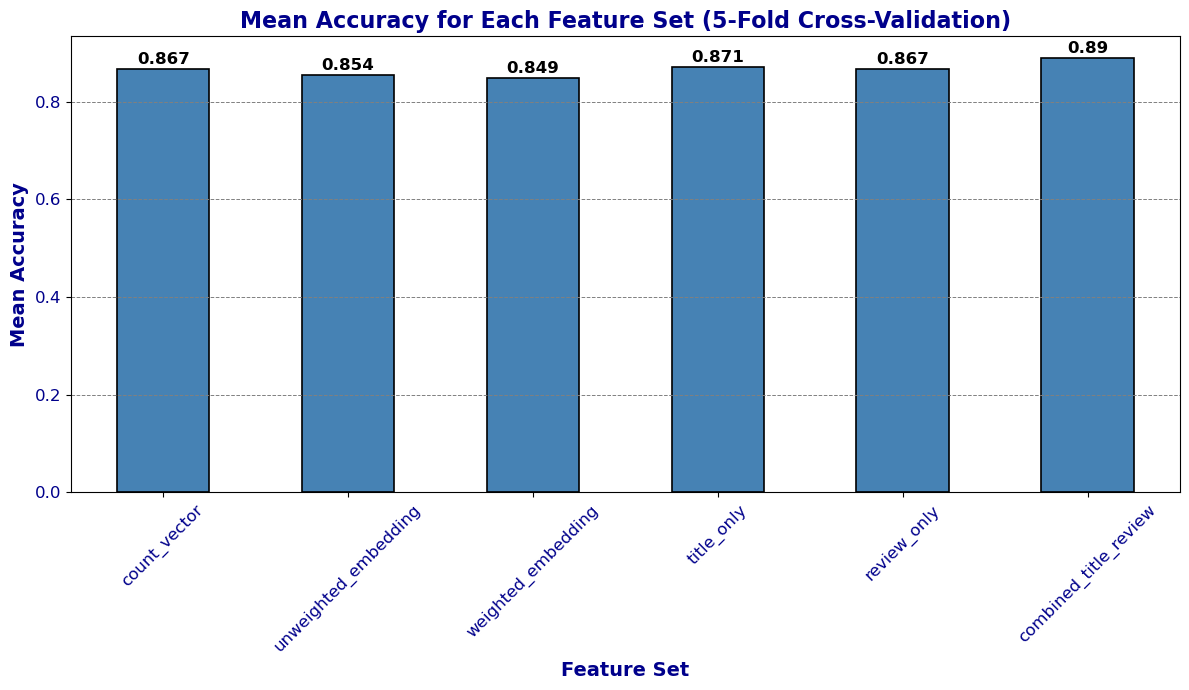

In [26]:
# Plot the mean accuracies for all models with enhanced aesthetics
plt.figure(figsize=(12, 7))

# Plot with enhanced colors and bar edge
bars = accuracy_df['Mean Accuracy'].plot(kind='bar', color='steelblue', edgecolor='black', linewidth=1.2)

# Add a title and labels with custom fonts
plt.title('Mean Accuracy for Each Feature Set (5-Fold Cross-Validation)', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Feature Set', fontsize=14, fontweight='bold', color='darkblue')
plt.ylabel('Mean Accuracy', fontsize=14, fontweight='bold', color='darkblue')

# Customize tick labels
plt.xticks(rotation=45, fontsize=12, color='darkblue')
plt.yticks(fontsize=12, color='darkblue')

# Add a grid for better readability
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.7, color='gray')

# Annotate each bar with the mean accuracy value
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3),
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Tighten layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()


The accuracy results, as summarized in the Accuracy DataFrame, reveal the performance of various feature extraction methods across five cross-validation folds. Notably, the Combined Title + Review feature set achieved the highest mean accuracy of 0.8915, indicating its effectiveness in classifying the reviews. In contrast, the Weighted Embeddings method yielded the lowest mean accuracy of 0.8487, suggesting that this approach may be less effective for the given classification task. These findings highlight the importance of feature representation in the predictive performance of classification models.


=== Mean Classification Report for Count Vector Model ===
Mean Precision: 0.8592
Mean Recall:    0.8592
Mean F1-Score:  0.8592

=== Mean Confusion Matrix for Count Vector Model ===


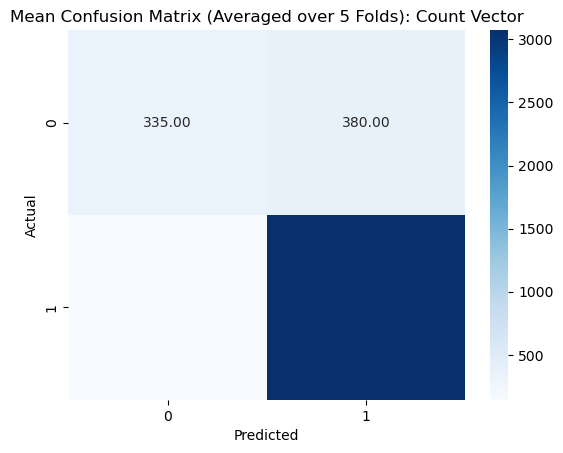


=== Mean Classification Report for Unweighted Embedding Model ===
Mean Precision: 0.8438
Mean Recall:    0.8438
Mean F1-Score:  0.8438

=== Mean Confusion Matrix for Unweighted Embedding Model ===


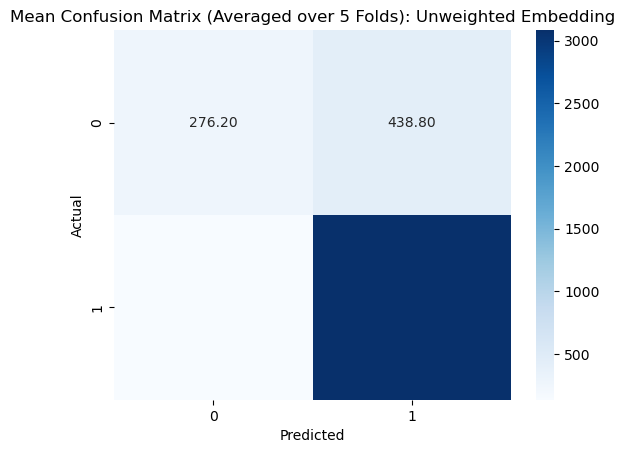


=== Mean Classification Report for Weighted Embedding Model ===
Mean Precision: 0.8362
Mean Recall:    0.8362
Mean F1-Score:  0.8362

=== Mean Confusion Matrix for Weighted Embedding Model ===


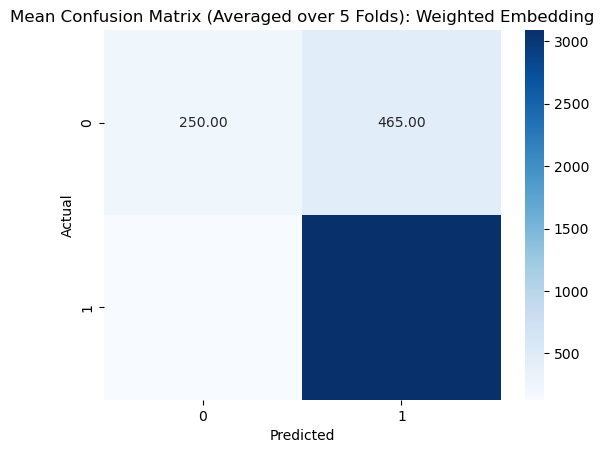


=== Mean Classification Report for Title Only Model ===
Mean Precision: 0.8644
Mean Recall:    0.8644
Mean F1-Score:  0.8644

=== Mean Confusion Matrix for Title Only Model ===


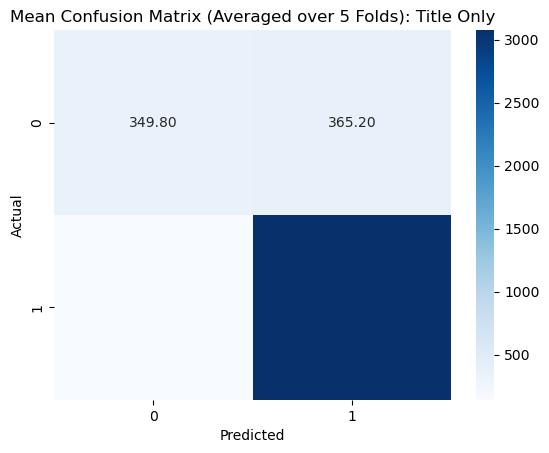


=== Mean Classification Report for Review Only Model ===
Mean Precision: 0.8593
Mean Recall:    0.8593
Mean F1-Score:  0.8593

=== Mean Confusion Matrix for Review Only Model ===


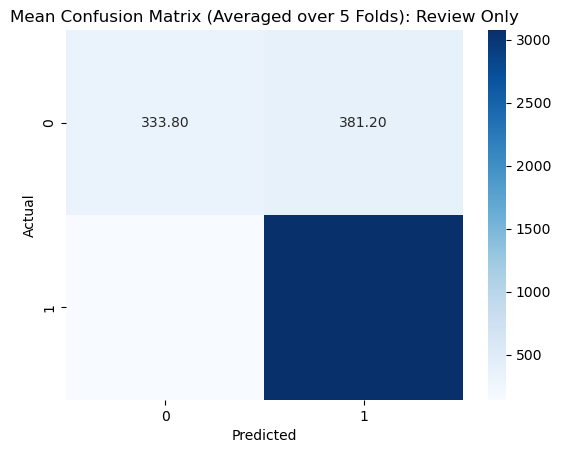


=== Mean Classification Report for Combined Title Review Model ===
Mean Precision: 0.8860
Mean Recall:    0.8860
Mean F1-Score:  0.8860

=== Mean Confusion Matrix for Combined Title Review Model ===


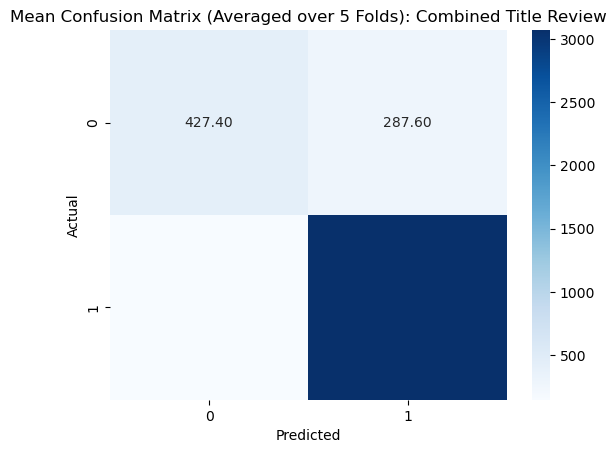

In [27]:
# Calculate the mean confusion matrix for each model
for model_name in conf_matrices.keys():
    mean_conf_matrix = conf_matrices[model_name] / num_folds  # Averaging confusion matrix over 5 folds
    mean_precision = np.mean(precision_list[model_name])
    mean_recall = np.mean(recall_list[model_name])
    mean_f1 = np.mean(f1_list[model_name])

    print(f"\n=== Mean Classification Report for {model_name.replace('_', ' ').title()} Model ===")
    print(f"Mean Precision: {mean_precision:.4f}")
    print(f"Mean Recall:    {mean_recall:.4f}")
    print(f"Mean F1-Score:  {mean_f1:.4f}")
    print(f"\n=== Mean Confusion Matrix for {model_name.replace('_', ' ').title()} Model ===")
    sns.heatmap(mean_conf_matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title(f"Mean Confusion Matrix (Averaged over 5 Folds): {model_name.replace('_', ' ').title()}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## Summary
- In Tasks 2 and 3, the **Logistic Regression** model was trained and evaluated using various feature extraction methods to predict customer recommendations from preprocessed review text.
- The feature extraction methods included:
  1. **Bag-of-Words (BoW)**
  2. **Unweighted Embeddings**
  3. **Weighted Embeddings**
  4. **Title**
  5. **Review**
  6. **Combinations of Title and Review text**
- Model performance was evaluated using **5-fold cross-validation**, highlighting significant differences between the feature extraction techniques.
- The **Combined Title + Review** feature set achieved the highest mean accuracy of **0.8915**, demonstrating its strong predictive capability.
- In contrast, the **Weighted Embeddings** method yielded the lowest mean accuracy of **0.8487**, suggesting it was less effective for this classification task.
- These results emphasize the importance of selecting appropriate feature representations to enhance the performance of machine learning models in text classification.
